--- Veri Seti Önizleme ---


,transaction_id,card_id,atm_id,amount,transaction_type,status,created_at
0,1,808,12,2896.76,çekim,başarılı,2026-06-12 10:45:28
1,2,315,1,406.40,sorgu,reddedildi,2026-06-22 15:15:03
2,3,930,9,2915.66,çekim,başarılı,2026-06-15 17:37:52
3,4,90,20,4659.88,yatırma,askıda,2026-06-20 19:25:42
4,5,265,7,4231.43,sorgu,başarılı,2026-06-08 20:27:23



--- Veri Tipleri ve Özet ---
<class 'pandas.DataFrame'>
RangeIndex: 50400 entries, 0 to 50399
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    50400 non-null  int64  
 1   card_id           50400 non-null  int64  
 2   atm_id            50400 non-null  int64  
 3   amount            50400 non-null  float64
 4   transaction_type  50400 non-null  str    
 5   status            50400 non-null  str    
 6   created_at        50400 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 2.7 MB

--- Sayısal Değişken İstatistikleri ---


,count,mean,std,min,25%,50%,75%,max
transaction_id,50400.0,25200.500000,14549.371120,1.00,12600.75,25200.50,37800.2500,50400.00
card_id,50400.0,600.188333,347.183635,1.00,297.00,598.00,904.0000,1200.00
atm_id,50400.0,10.475734,5.759295,1.00,5.00,10.00,15.0000,20.00
amount,50400.0,4202.206913,13043.686484,10.14,1254.73,2493.89,3744.4825,149945.08


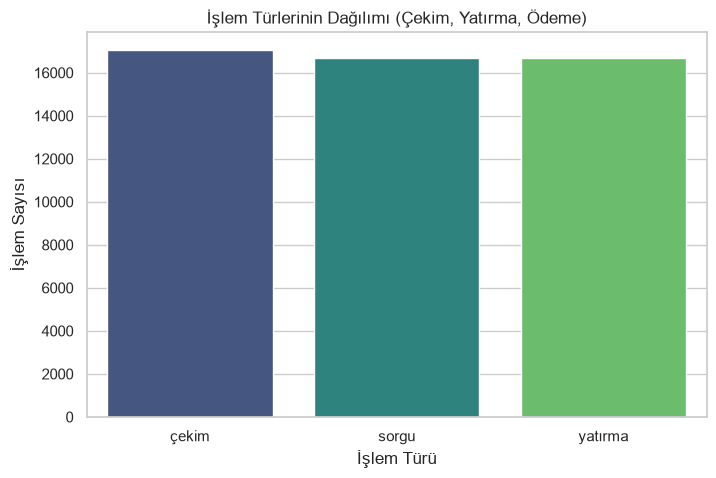

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Seaborn stil ayarları
sns.set_theme(style="whitegrid")

# 1. Temizlenmiş Veriyi Yükleme
df = pd.read_csv('../data_generation/output/transactions.csv')

# İlk 5 satırı inceleme
print("--- Veri Seti Önizleme ---")
display(df.head())

# Veri seti genel bilgileri ve eksik değer kontrolü
print("\n--- Veri Tipleri ve Özet ---")
df.info()

# 2. Temel İstatistiksel Özetler (Tutar, İşlem Tipleri vb.)
print("\n--- Sayısal Değişken İstatistikleri ---")
display(df.describe().T)

# 3. İşlem Türlerine Göre Dağılım Analizi
# Güncellenmiş ve uyarısız kod
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='transaction_type', hue='transaction_type', palette='viridis', legend=False)
plt.title('İşlem Türlerinin Dağılımı (Çekim, Yatırma, Ödeme)')
plt.xlabel('İşlem Türü')
plt.ylabel('İşlem Sayısı')
plt.show()

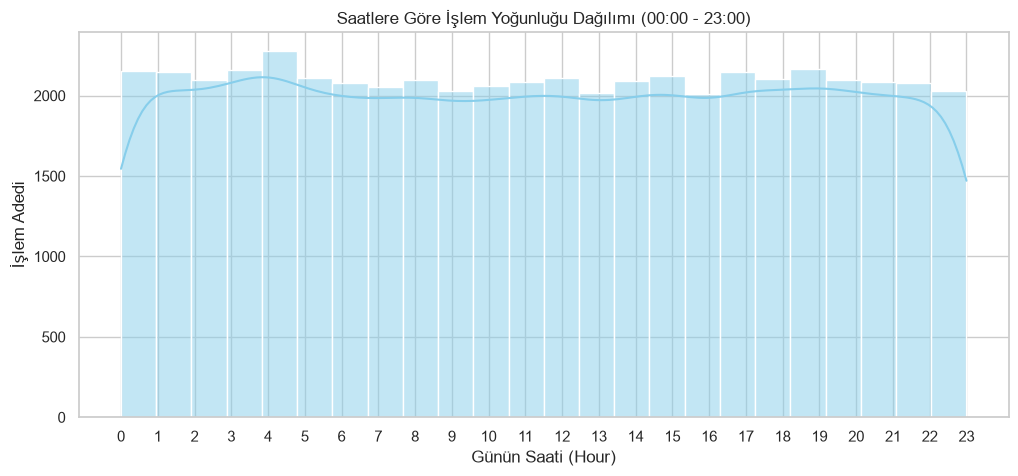

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# 'created_at' veya 'transaction_date' sütununu datetime formatına çevirelim
df['created_at'] = pd.to_datetime(df['created_at'])
df['hour'] = df['created_at'].dt.hour

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='hour', bins=24, kde=True, color='skyblue')
plt.title('Saatlere Göre İşlem Yoğunluğu Dağılımı (00:00 - 23:00)')
plt.xlabel('Günün Saati (Hour)')
plt.ylabel('İşlem Adedi')
plt.xticks(range(0, 24))
plt.show()

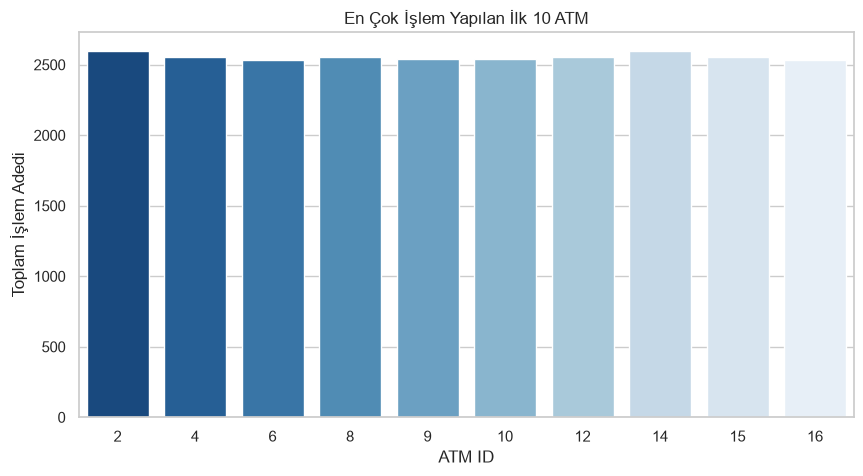

In [5]:
plt.figure(figsize=(10, 5))
top_atms = df['atm_id'].value_counts().head(10)
sns.barplot(x=top_atms.index, y=top_atms.values, palette='Blues_r')
plt.title('En Çok İşlem Yapılan İlk 10 ATM')
plt.xlabel('ATM ID')
plt.ylabel('Toplam İşlem Adedi')
plt.show()

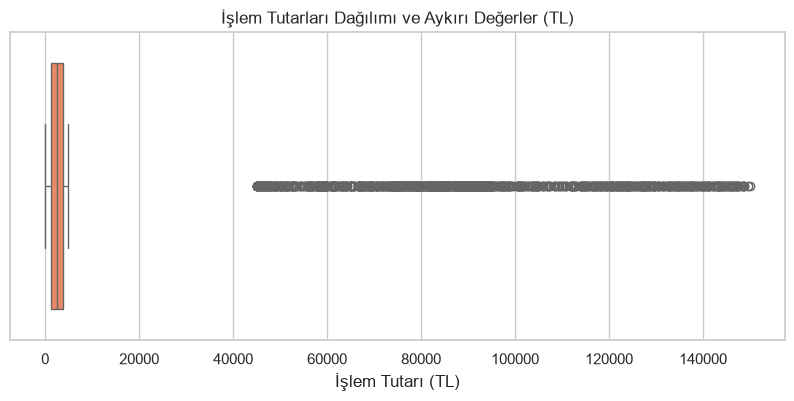

Üçüncü Çeyrek (Q3): 3744.48 TL
Aykırı Değer Eşiği (Upper Bound): 7479.11 TL
Eşik Üstü İşlem Sayısı: 993 adet


In [6]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['amount'], color='coral')
plt.title('İşlem Tutarları Dağılımı ve Aykırı Değerler (TL)')
plt.xlabel('İşlem Tutarı (TL)')
plt.show()

# İstatistiki aykırı değer özet verisi
q1 = df['amount'].quantile(0.25)
q3 = df['amount'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)

print(f"Üçüncü Çeyrek (Q3): {q3:.2f} TL")
print(f"Aykırı Değer Eşiği (Upper Bound): {upper_bound:.2f} TL")
print(f"Eşik Üstü İşlem Sayısı: {(df['amount'] > upper_bound).sum()} adet")